# Assignment 7 — Kernels and Random Feature Maps: Demo

This notebook runs the main experiment scripts and displays the resulting plots inline, as a quick visual summary of the project's key results.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

print("Working directory:", os.getcwd())

Working directory: /Users/ludovicopassoni/Desktop/SMML_project/notebook


In [2]:
#import all the functions from the experiments module
from experiments.common import load_all_datasets
from experiments.run_experiment import run_experiment, plot_results
from experiments.gamma_effect import run_gamma_experiment, plot_gamma_effect, make_gamma_list
from experiments.feature_map_comparison import evaluate_polynomial_features
from experiments.runtime_accuracy import collect_runtime_accuracy_data, plot_runtime_accuracy

In [3]:
#load the datasets
datasets = load_all_datasets()
X_train_synth, X_test_synth, y_train_synth, y_test_synth = datasets["synthetic"]
X_train_real, X_test_real, y_train_real, y_test_real = datasets["real"]

In [4]:
import matplotlib.pyplot as plt
def plot_results_inline(n_components_list, train_accs, test_accs, baseline_test_acc, kernel_test_acc, dataset_name):
    plt.plot(n_components_list, test_accs, marker="o", label="RFF + Linear (test)")
    plt.plot(n_components_list, train_accs, marker="o", label="RFF + Linear (train)")
    plt.axhline(y=baseline_test_acc, color='r', linestyle='--', label="Linear SVM (test)")
    plt.axhline(y=kernel_test_acc, color='g', linestyle='--', label="Kernel SVM (test)")
    plt.xscale('log')
    plt.xlabel("Number of Random Fourier Features (D)")
    plt.ylabel("Accuracy")
    plt.title(f"Performance on {dataset_name} dataset")
    plt.legend()
    plt.grid()
    plt.show()
def plot_gamma_effect_inline(gamma_list, train_accs, test_accs, dataset_name):
    plt.figure()
    plt.plot(gamma_list, train_accs, marker="o", label="Train accuracy")
    plt.plot(gamma_list, test_accs, marker="o", label="Test accuracy")
    plt.xscale("log")
    plt.xlabel("gamma")
    plt.ylabel("Accuracy")
    plt.title(f"Effect of RBF bandwidth (gamma) on {dataset_name} dataset")
    plt.legend()
    plt.grid()
    plt.show()
def plot_runtime_accuracy_inline(results, dataset_name):
    labels, times, accs = zip(*results)

    plt.figure()
    plt.scatter(times, accs)
    plt.xscale("log")
    plt.xlabel("Training time (seconds)")
    plt.ylabel("Test accuracy")
    plt.title(f"Runtime vs Accuracy trade-off ({dataset_name})")
    plt.grid()

    for label, t, acc in zip(labels, times, accs):
        plt.annotate(label, (t, acc), textcoords="offset points", xytext=(0,10), ha='center')
    plt.show()

## 1. Synthetic Dataset (XOR pattern)

The synthetic dataset is designed to be non-linearly separable by construction, so that a linear model cannot solve it well while kernel methods can.

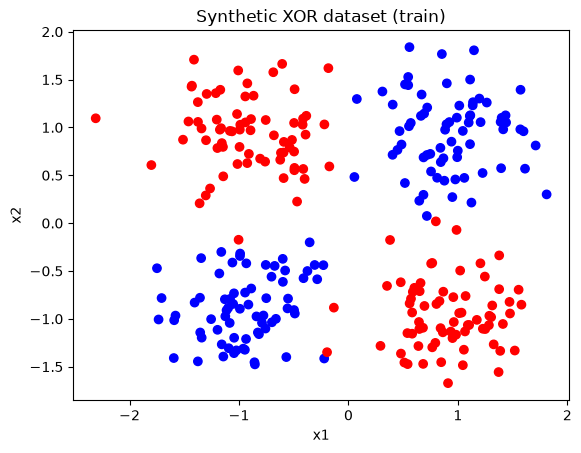

In [5]:
import matplotlib.pyplot as plt

plt.scatter(X_train_synth[:, 0], X_train_synth[:, 1], c=y_train_synth, cmap="bwr")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic XOR dataset (train)")
plt.show()

## 2. Linear vs. Kernel vs. Random Fourier Features

Comparison of the three models on both datasets, varying the number of random features (D) used by RFF.

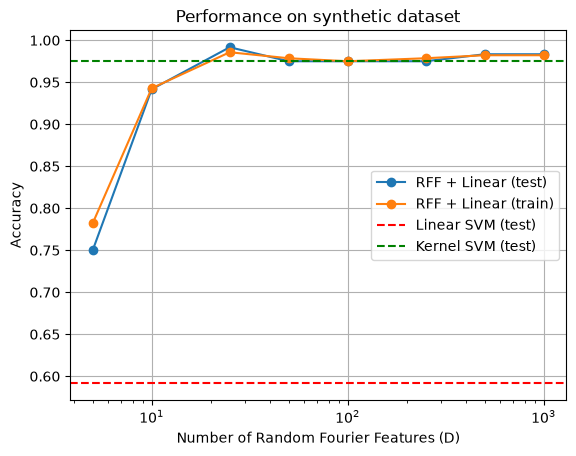

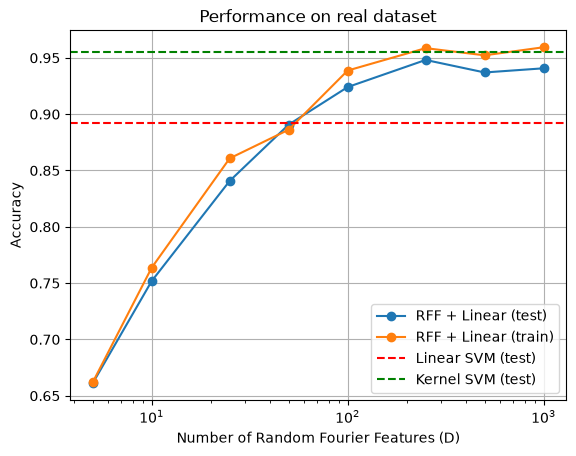

[synthetic] baseline=0.5917, kernel=0.9750, best RFF=0.9917
[real] baseline=0.8926, kernel=0.9556, best RFF=0.9481


In [6]:
n_components_list = [5, 10, 25, 50, 100, 250, 500, 1000]
results_synth = run_experiment(X_train_synth, X_test_synth, y_train_synth, y_test_synth, n_components_list, "synthetic")
results_real = run_experiment(X_train_real, X_test_real, y_train_real, y_test_real, n_components_list, "real")
plot_results_inline(n_components_list, results_synth[0], results_synth[1], results_synth[2], results_synth[3], "synthetic")
plot_results_inline(n_components_list, results_real[0], results_real[1], results_real[2], results_real[3], "real")
print(f"[synthetic] baseline={results_synth[2]:.4f}, kernel={results_synth[3]:.4f}, best RFF={max(results_synth[1]):.4f}")
print(f"[real] baseline={results_real[2]:.4f}, kernel={results_real[3]:.4f}, best RFF={max(results_real[1]):.4f}")

## 3. Effect of the RBF Bandwidth (gamma)

How the RBF kernel bandwidth affects training and test accuracy on both datasets.

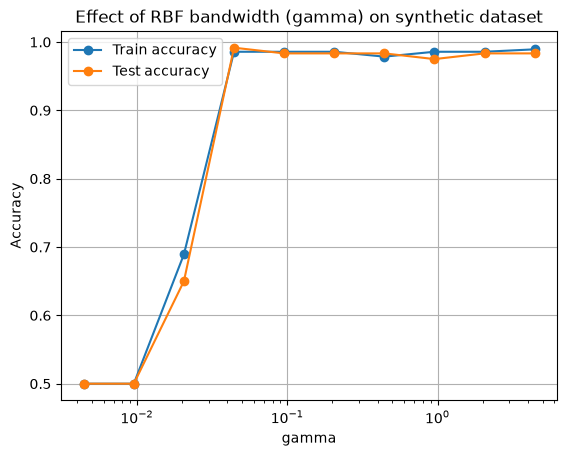

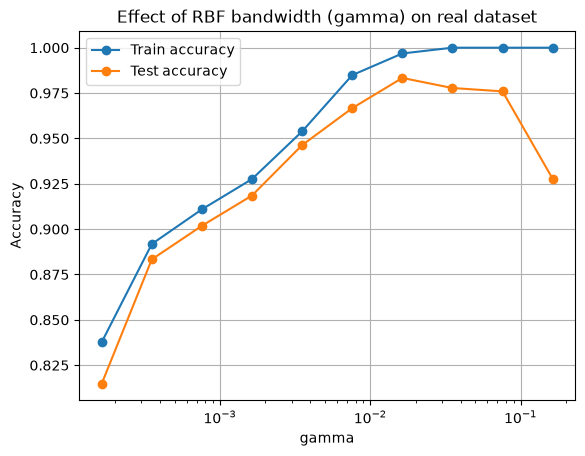

[synthetic] min test acc=0.5000, max test acc=0.9917
[real] min test acc=0.8148, max test acc=0.9833


In [7]:
gamma_list_synth = make_gamma_list(X_train_synth)
train_accs_gamma_synth, test_accs_gamma_synth = run_gamma_experiment(X_train_synth, X_test_synth, y_train_synth, y_test_synth, gamma_list_synth, "synthetic")
plot_gamma_effect_inline(gamma_list_synth, train_accs_gamma_synth, test_accs_gamma_synth, "synthetic")

gamma_list_real = make_gamma_list(X_train_real)
train_accs_gamma_real, test_accs_gamma_real = run_gamma_experiment(X_train_real, X_test_real, y_train_real, y_test_real, gamma_list_real, "real")
plot_gamma_effect_inline(gamma_list_real, train_accs_gamma_real, test_accs_gamma_real, "real")

print(f"[synthetic] min test acc={min(test_accs_gamma_synth):.4f}, max test acc={max(test_accs_gamma_synth):.4f}")
print(f"[real] min test acc={min(test_accs_gamma_real):.4f}, max test acc={max(test_accs_gamma_real):.4f}")

## 4. RFF vs. Explicit Polynomial Feature Map

Comparing the RFF approximation to an exact but combinatorially-growing polynomial feature map.

In [8]:
degrees = [2, 3]

for dataset_name, (X_train, X_test, y_train, y_test) in datasets.items():
    for degree in degrees:
        train_acc, test_acc, n_features = evaluate_polynomial_features(X_train, X_test, y_train, y_test, degree)
        print(f"[{dataset_name}] degree={degree}: train_acc={train_acc:.4f}, test_acc={test_acc:.4f}, n_features={n_features}")

[synthetic] degree=2: train_acc=0.9857, test_acc=0.9917, n_features=6
[synthetic] degree=3: train_acc=0.9857, test_acc=0.9917, n_features=10
[real] degree=2: train_acc=1.0000, test_acc=0.9741, n_features=2145
[real] degree=3: train_acc=1.0000, test_acc=0.9759, n_features=47905


## 5. Runtime vs. Accuracy Trade-off

Training time vs. test accuracy for each model/configuration.

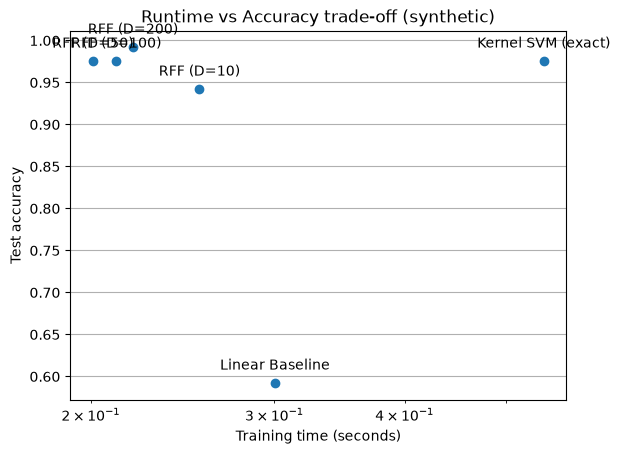

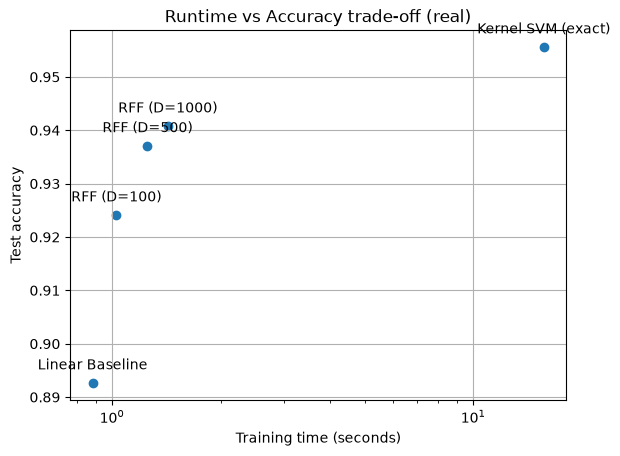

[synthetic] Linear Baseline: time=0.3004s, test_acc=0.5917
[synthetic] Kernel SVM (exact): time=0.5437s, test_acc=0.9750
[synthetic] RFF (D=10): time=0.2541s, test_acc=0.9417
[synthetic] RFF (D=50): time=0.2008s, test_acc=0.9750
[synthetic] RFF (D=100): time=0.2115s, test_acc=0.9750
[synthetic] RFF (D=200): time=0.2194s, test_acc=0.9917
[real] Linear Baseline: time=0.8836s, test_acc=0.8926
[real] Kernel SVM (exact): time=15.6625s, test_acc=0.9556
[real] RFF (D=100): time=1.0268s, test_acc=0.9241
[real] RFF (D=500): time=1.2524s, test_acc=0.9370
[real] RFF (D=1000): time=1.4255s, test_acc=0.9407


In [9]:
results_runtime_synth = collect_runtime_accuracy_data(X_train_synth, X_test_synth, y_train_synth, y_test_synth, [10, 50, 100, 200], "synthetic")
results_runtime_real = collect_runtime_accuracy_data(X_train_real, X_test_real, y_train_real, y_test_real, [100, 500, 1000], "real")
plot_runtime_accuracy_inline(results_runtime_synth, "synthetic")
plot_runtime_accuracy_inline(results_runtime_real, "real")
for label, runtime, acc in results_runtime_synth:
        print(f"[synthetic] {label}: time={runtime:.4f}s, test_acc={acc:.4f}")
for label, runtime, acc in results_runtime_real:
        print(f"[real] {label}: time={runtime:.4f}s, test_acc={acc:.4f}")

## Summary

This notebook reproduces the key results discussed in the report. For full experimental details, hyperparameter choices, and discussion, see `report/report.pdf`.